#### Usage: 

1. To run the BO-DBA attck:
   In order to check the efficiency of the BO-DBA attac with different models, please use any    of these model names -> perlin, gabor, BICU, BILI, CLUSTER, NN, in place of the blank        space given in this (noiseGenerator = '       ') in cell number 5.
   
2. To run the HJSA attack:
   In order to check the efficiency of the BO-DBA attac with different models, please use any    of these model names -> norm,l2,linf,in place of the blank space given in this (constraint    = '    ') in cell number 6.


In [ ]:
from warnings import simplefilter 
simplefilter(action='ignore', category=FutureWarning)
import random

# according to keras docs keras.preprocessing API was deprecated
# from  keras.preprocessing.image import save_img
from tensorflow.keras.utils import save_img
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
import io
import os
import yaml
from python_files.Util import *
from IPython import display
import copy
%matplotlib inline

In [ ]:
import tensorflow as tf

physical_devices = tf.config.experimental.list_physical_devices("GPU")

if physical_devices:
    for gpu in physical_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"TensorFlow detected {len(physical_devices)} GPU(s).", flush=True)
else:
    print("No GPUs detected. Sorry buddy, it's CPUs for you.", flush=True)

In [ ]:
#Global configuration
attackMode = 'Raw' #Raw: means without defense, Detection: With adversarial exmaples detection, Target means targeted attack
queryBudgets = 500 #Query Budgets
random.seed(42) #Set random seeds

In [ ]:
#Select random target image
oriImg= randomimg(mode = attackMode,target=0)
display_images(oriImg.img)

In [ ]:
#BO-DBA attack
from python_files.BODBA import bayesian_attack
noiseGenerator = 'perlin'#Options: perlin; gabor; BICU; BILI; CLUSTER; NN
constraint = 'linf'#norm: l2; linf
oriImg_copy = copy.deepcopy(oriImg)
with tf.device('/GPU:0'): 
        timehistory,adversarial = bayesian_attack(oriImg_copy,max_query=queryBudgets,
                                                             noise=noiseGenerator,constraint=constraint,init_query=5)
print(adversarial.shape)
print('Attack result: L2:{0}, Linf:{1}'.format(oriImg_copy.maxl2,oriImg_copy.maxlinf))
History=[oriImg_copy.historyl2,oriImg_copy.historylinf,timehistory]
        
DemoVisulization(oriImg_copy.img,adversarial,History,queryBudgets)

In [ ]:
#HJSA attack
from python_files.HJSA import hsja
constraint = 'linf'#norm: l2; linf
oriImg_copy = copy.deepcopy(oriImg)
with tf.device('/GPU:0'): 
        timehistory,adversarial = hsja(oriImg_copy,constraint=constraint,
                                                  max_query=queryBudgets,verbose=False)
if adversarial is None:
    print('Initialisation failed')
else:
    print('Attack result: L2:{0}, Linf:{1}'.format(oriImg_copy.maxl2,oriImg_copy.maxlinf))
    History=[oriImg_copy.historyl2,oriImg_copy.historylinf,timehistory]
    DemoVisulization(oriImg_copy.img,adversarial,History,queryBudgets)

In [ ]:
#RayS attack
from python_files.RayS import RayS
oriImg_copy = copy.deepcopy(oriImg)
attack = RayS(oriImg_copy,order=np.inf, epsilon=0.3, early_stopping=False)
with tf.device('/GPU:0'):
    timehistory,adversarial=attack.attack_hard_label(query_limit=queryBudgets)
print('Attack result: L2:{0}, Linf:{1}'.format(oriImg_copy.maxl2,oriImg_copy.maxlinf))
History=[oriImg_copy.historyl2,oriImg_copy.historylinf,timehistory]
        
DemoVisulization(oriImg_copy.img,adversarial,History,queryBudgets)

Searching for the initial direction on 100 random directions: 
--------> Found distortion 98.5799
--------> Found distortion 82.0125
--------> Found distortion 73.9341
--------> Found distortion 71.8261
--------> Found distortion 61.2444
--------> Found distortion 60.1978
==========> Found best distortion 60.1978 in 18.1410 seconds using 297 queries: 302


  0%|          | 0/500 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Attack result: L2:38.670841354001176, Linf:0.35548789333697783


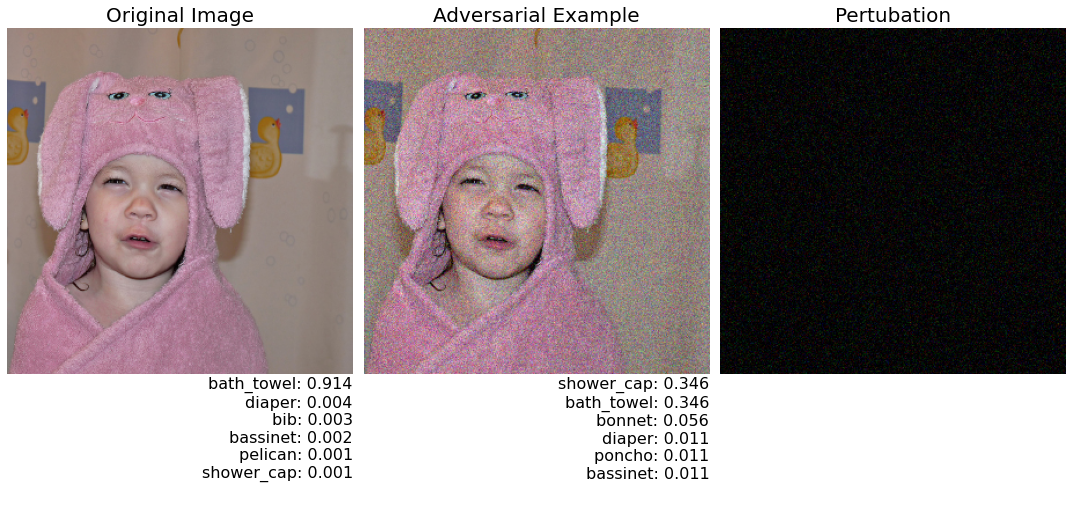

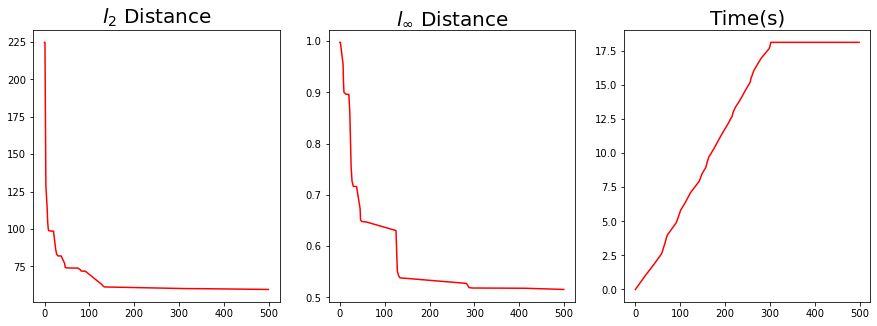

In [15]:
#SignOPT attack
from python_files.SignOPT import OPT_attack_sign_SGD
oriImg_copy = copy.deepcopy(oriImg)
attack = OPT_attack_sign_SGD(oriImg_copy)
with tf.device('/GPU:0'):
    timehistory,adversarial=attack.attack_untargeted(query_limit=queryBudgets)
print('Attack result: L2:{0}, Linf:{1}'.format(oriImg_copy.maxl2,oriImg_copy.maxlinf))
History=[oriImg_copy.historyl2,oriImg_copy.historylinf,timehistory]
        
DemoVisulization(oriImg_copy.img,adversarial,History,queryBudgets)